In [1]:
import phydrus as ps
print(ps.__version__)
print(ps.__dir__())

0.2.0
['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__path__', '__file__', '__cached__', '__builtins__', 'plot', 'decorators', 'read', 'version', 'model', 'Model', 'profile', 'create_profile', 'read_profile', 'read_nod_inf', 'read_run_inf', 'read_tlevel', 'read_balance', 'read_i_check', 'read_obs_node', 'read_alevel', 'read_solute', 'getLogger', 'utils', 'show_versions', 'set_log_level', '_initialize_logger', '__version__', 'logger']


INFO: Successfully wrote small_example/SELECTOR.IN
INFO: Successfully wrote small_example/PROFILE.DAT
INFO: Hydrus-1D Simulation Successful.


<Axes: xlabel='h [cm]', ylabel='depth [cm]'>

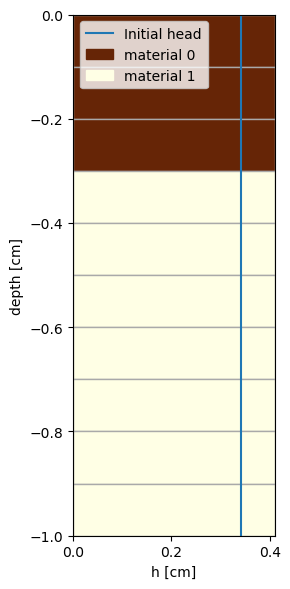

In [2]:
"""
Demonstrates a simple 1D vertical water flow simulation using phydrus 0.2.0.
Initializes a 100cm soil column with a constant pressure head boundary.
"""

# Define the model workspace and executable path
ws = 'small_example'
exe = '/opt/hydrus1d/bin/hydrus'

# Create the basic model
desc = "Infiltration and drainage in a large caisson"

ml = ps.Model(exe_name=exe, ws_name=ws, name="model", description=desc,
              mass_units="mmol", time_unit="min", length_unit="cm")

times = ml.add_time_info(tinit=90, tmax=273, print_times=True, dt=0.1,
                         dtmax=0.5, printinit=120)

ml.add_waterflow(top_bc=1, bot_bc=0, rtop=0)

m = ml.get_empty_material_df(n=2)
m.loc[1:2] = [[0.08, 0.3421, 0.03, 5, 1, -0.5],
              [0.08, 0.3421, 0.03, 5, 0.1, -0.5]]

ml.add_material(m)

profile = ps.create_profile(h=0.342)
profile.loc[5:11, "Mat"] = 2
ml.add_profile(profile)

# atm = pd.read_csv("seep/orig/ATMOSPH.IN", skiprows=5, skipfooter=1,
#                   skipinitialspace=True, delim_whitespace=True)
# ml.add_atmosphere(atm)

ml.write_input()
rs = ml.simulate()
ml.plots.profile()

In [3]:
df = ml.read_tlevel()
df['vBot[L/T]'].plot()

TypeError: read_csv() got an unexpected keyword argument 'delim_whitespace'